In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [23]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [24]:
!pip install -r ../requirements.txt

In [25]:
import sys
import os
from datasets import load_dataset

# Добавляем родительсs_кую папку в путь поиска Python
sys.path.append(os.path.abspath('..'))

# Теперь можно импортировать
from src.data_fetch import data_fetch

df = data_fetch()

# Type of forests

In [26]:
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.nunique()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

31374648.000038706
29578970.3090813
28256399.30450555
27567898.69425421
26966884.154038586
26286819.785034742
25658180.52706263


ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

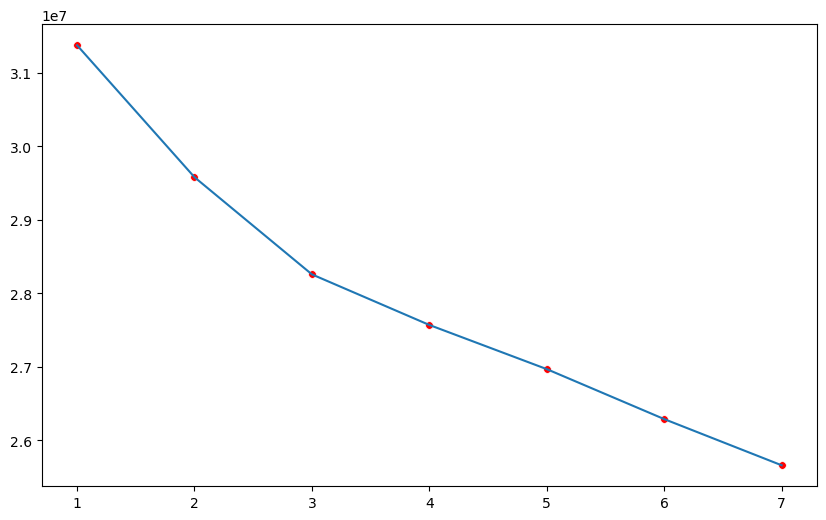

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

css = []
for k in range(1, 8):
    model_kmeans = KMeans(n_clusters= k, n_init= 10, random_state= 42)
    model_kmeans.fit(X_scaled)
    print(model_kmeans.inertia_)
    # for elbow plot
    css.append(model_kmeans.inertia_)

fig =plt.figure(figsize = (10, 6))
plt.plot(np.arange(1, 8), css)
sns.scatterplot(x = np.arange(1, 8), y = css, color = 'red', s = 30, legend= 'Значения CSS')
plt.ylabel("css. internal cluster destinations")
plt.xlabel('clusters number')
pplt.show()

k=1, inertia=1162024.00
k=2, inertia=704709.09
k=3, inertia=376322.40
k=4, inertia=289802.25
k=5, inertia=220006.62
k=6, inertia=190896.88
k=7, inertia=168207.38


Text(0.5, 0, 'clusters number')

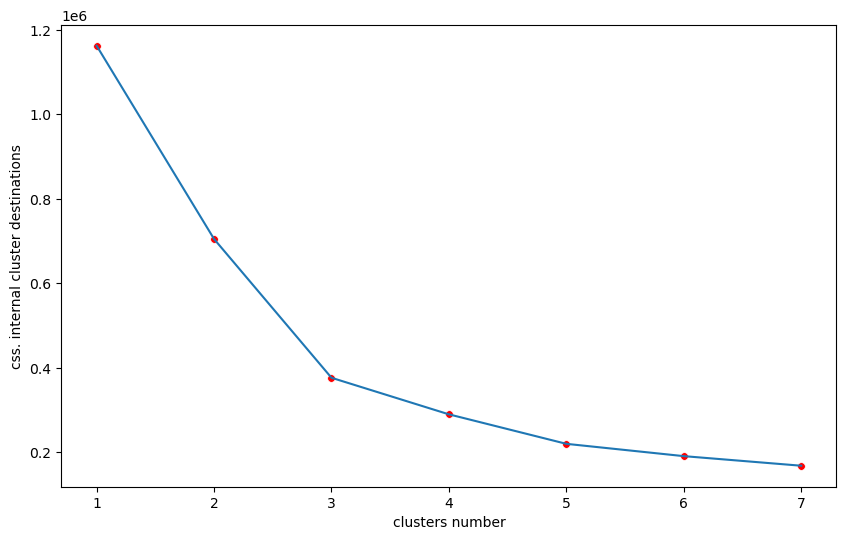

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)
X_centered = X_scaled - X_scaled.mean(axis = 0)
# calculates most useful features by unique elements variance
X_pca = pca.fit_transform(X_centered)

scaler2 = StandardScaler()
X_pca_normalized = scaler2.fit_transform(X_pca)

css = []
for k in range(1, 8):
    model_kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    model_kmeans.fit(X_pca_normalized)
    print(f"k={k}, inertia={model_kmeans.inertia_:.2f}")
    css.append(model_kmeans.inertia_)

fig =plt.figure(figsize = (10, 6))
plt.plot(np.arange(1, 8), css)
sns.scatterplot(x = np.arange(1, 8), y = css, color = 'red', s = 30)
plt.ylabel("css. internal cluster destinations")
plt.xlabel('clusters number')




0.3907944617627161
0.4514540797589713
0.42155221921568115
0.4274980844095991
0.4270237476676603
0.40574943458707546


C:\Users\Nemat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Nemat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Nemat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Nemat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

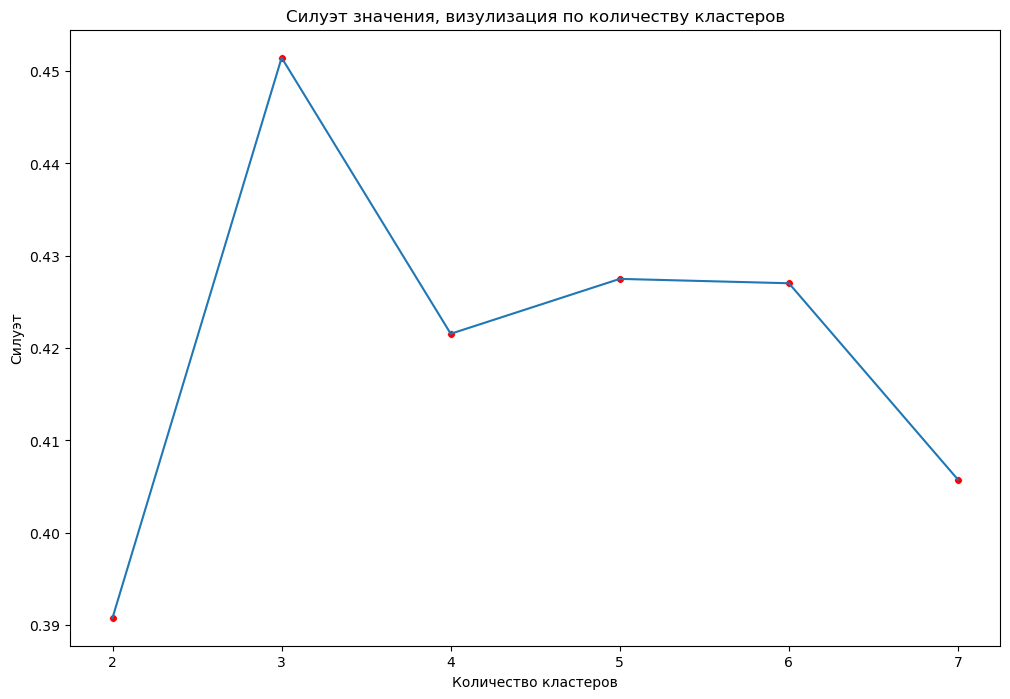

In [30]:
from sklearn.metrics import silhouette_score

X_pca_normalized = pd.DataFrame(X_pca_normalized)
X_pca_normalized = X_pca_normalized.sample(n = 100, random_state = 42)


silhouette_scores = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters= k, n_init= 10, random_state= 42)
    kmeans.fit(X_pca_normalized)
    labels_X_scaled = kmeans.labels_
    sil_score = silhouette_score(X_pca_normalized, labels_X_scaled)
    print(sil_score)
    silhouette_scores.append(sil_score)

fig = plt.figure(figsize= (12, 8))
plt.plot(np.arange(2, 8), silhouette_scores)
plt.title('Силуэт значения, визулизация по количеству кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Силуэт')
sns.scatterplot(x = np.arange(2, 8), y = silhouette_scores, color = 'red', s = 30, legend= 'Значения Силуэтаээ')
plt.legend('Значения [-1, 1];стремление к 1 - идеальная кластеризация')


# n_clusters = 3 | 7


C:\Users\Nemat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 1.0, 'Type of forest')

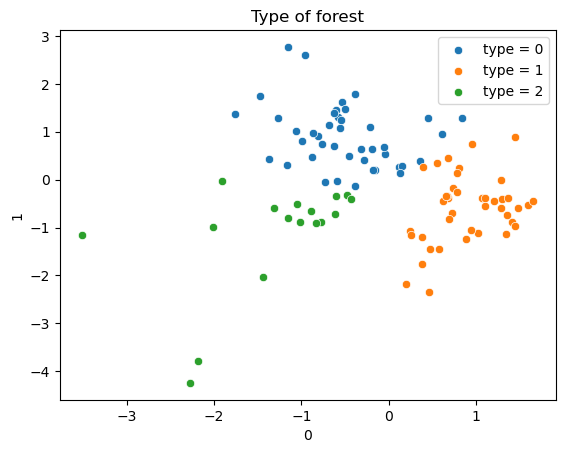

In [31]:
kmeans = KMeans(n_clusters= 3, n_init = 10)
kmeans.fit(X_pca_normalized)
labels = kmeans.labels_

sns.scatterplot(data = X_pca_normalized[labels == 0], x = X_pca_normalized.columns[0], 
                y = X_pca_normalized.columns[1], label = 'type = 0')
sns.scatterplot(data = X_pca_normalized[labels == 1], x = X_pca_normalized.columns[0], 
                y = X_pca_normalized.columns[1], label = 'type = 1')
sns.scatterplot(data = X_pca_normalized[labels == 2], x = X_pca_normalized.columns[0], 
                y = X_pca_normalized.columns[1], label = 'type = 2')
plt.title('Type of forest')



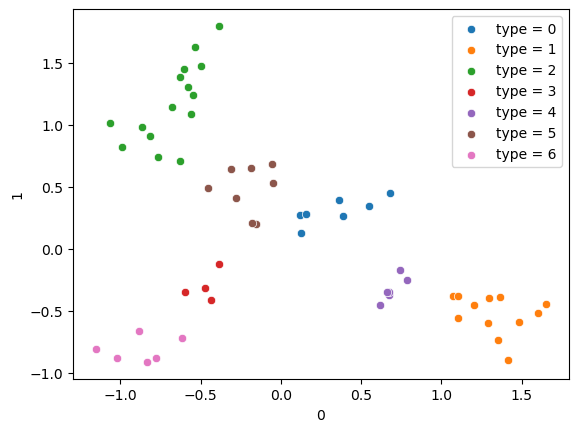

In [35]:
from sklearn.cluster import DBSCAN
# min_samples parameter detection
min_samples = X_pca_normalized.shape[1] * 2

model_dbscan = DBSCAN(min_samples= min_samples, eps= 1 / min_samples)
model_dbscan.fit(X_pca_normalized)
labels = model_dbscan.labels_

for label in range(len(labels)):
    if label == -1:
        sns.scatterplot(data=X_pca_normalized[labels == label], 
                       x=X_pca_normalized.columns[0], 
                       y=X_pca_normalized.columns[1], 
                       label='Шум', color='gray')
    else:
        sns.scatterplot(data=X_pca_normalized[labels == label], 
                       x=X_pca_normalized.columns[0], 
                       y=X_pca_normalized.columns[1], 
                       label=f'type = {label}')